# 🐦 Bird Species Image Classification Project

CS 3793 – Artificial Intelligence  
Team Members: John Quach, Edison La, Khoa Nguyen, Boyu Chen

This notebook contains our full project pipeline for bird species image classification using computer vision.  
We train and compare multiple models:
- **Method 1:** Baseline CNN (built from scratch)  
- **Method 2:** Transfer Learning with ResNet50
- **Method 3:** Transfer Learning with EfficientNet  

Our goal is to see how transfer learning improves accuracy and generalization compared to a simple CNN.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


#Importing bird.zip attained from kaggle

In [ ]:
ZIP_PATH = '/content/drive/MyDrive/Bird Project/datasets/bird.zip'
DEST_DIR = '/content/birds'

!mkdir -p {DEST_DIR}
!unzip -q -o "{ZIP_PATH}" -d {DEST_DIR}
!ls -R {DEST_DIR} | head -n 30

/content/birds:
Test
Train

/content/birds/Test:
Acadian_Flycatcher
American_Crow
American_Goldfinch
American_Pipit
American_Redstart
American_Three_toed_Woodpecker
Anna_Hummingbird
Artic_Tern
Baird_Sparrow
Baltimore_Oriole
Bank_Swallow
Barn_Swallow
Bay_breasted_Warbler
Belted_Kingfisher
Bewick_Wren
Black_and_white_Warbler
Black_billed_Cuckoo
Black_capped_Vireo
Black_footed_Albatross
Black_Tern
Black_throated_Blue_Warbler
Black_throated_Sparrow
Blue_Grosbeak
Blue_headed_Vireo
Blue_Jay


In [ ]:
import os, re, shutil, random
from collections import Counter

RAW_ROOT   = '/content/birds'
CLEAN_DIR  = '/content/bird_clean'
SPLIT_DIR  = '/content/bird_split'
MIN_PER_CLASS = 4
SPLITS = {'train':0.7, 'val':0.15, 'test':0.15}
EXTS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

for p in [CLEAN_DIR, SPLIT_DIR]:
    shutil.rmtree(p, ignore_errors=True)
    os.makedirs(p, exist_ok=True)

all_imgs = []
for dp, dn, fn in os.walk(RAW_ROOT):
    for f in fn:
        if f.lower().endswith(EXTS):
            all_imgs.append(os.path.join(dp, f))
print('Total images found:', len(all_imgs))

def extract_label(path):
    parent = os.path.basename(os.path.dirname(path))
    return parent.strip().lower().replace(' ', '_')

labels = [extract_label(p) for p in all_imgs]
counts = Counter(labels)
keep = {lab for lab, c in counts.items() if c >= MIN_PER_CLASS}
print('Classes kept:', len(keep))
print('Kept (sample):', sorted(list(keep))[:12])

kept = 0
for p, lab in zip(all_imgs, labels):
    if lab in keep:
        out_dir = os.path.join(CLEAN_DIR, lab)
        os.makedirs(out_dir, exist_ok=True)
        shutil.copy2(p, os.path.join(out_dir, os.path.basename(p)))
        kept += 1
print('Images copied into clean class folders:', kept)

random.seed(42)
for split in SPLITS:
    os.makedirs(os.path.join(SPLIT_DIR, split), exist_ok=True)

for lab in sorted(os.listdir(CLEAN_DIR)):
    src = os.path.join(CLEAN_DIR, lab)
    if not os.path.isdir(src):
        continue
    imgs = [f for f in os.listdir(src) if f.lower().endswith(EXTS)]
    random.shuffle(imgs)
    n = len(imgs)
    n_train = max(1, int(n * SPLITS['train']))
    n_val   = max(1, int(n * SPLITS['val']))
    n_test  = max(1, n - n_train - n_val)
    splits = {
        'train': imgs[:n_train],
        'val':   imgs[n_train:n_train+n_val],
        'test':  imgs[n_train+n_val:n_train+n_val+n_test],
    }
    for sp, lst in splits.items():
        out_dir = os.path.join(SPLIT_DIR, sp, lab)
        os.makedirs(out_dir, exist_ok=True)
        for name in lst:
            shutil.copy2(os.path.join(src, name), os.path.join(out_dir, name))

for sp in ['train', 'val', 'test']:
    print(f'== {sp} ==')
    root = os.path.join(SPLIT_DIR, sp)
    for lab in sorted(os.listdir(root)):
        cnt = len(os.listdir(os.path.join(root, lab)))
        print(f'{lab:20s} {cnt}')

Total images found: 11788
Classes kept: 200
Kept (sample): ['acadian_flycatcher', 'american_crow', 'american_goldfinch', 'american_pipit', 'american_redstart', 'american_three_toed_woodpecker', 'anna_hummingbird', 'artic_tern', 'baird_sparrow', 'baltimore_oriole', 'bank_swallow', 'barn_swallow']
Images copied into clean class folders: 11788
== train ==
acadian_flycatcher   41
american_crow        42
american_goldfinch   42
american_pipit       42
american_redstart    42
american_three_toed_woodpecker 35
anna_hummingbird     42
artic_tern           40
baird_sparrow        35
baltimore_oriole     42
bank_swallow         41
barn_swallow         42
bay_breasted_warbler 42
belted_kingfisher    42
bewick_wren          42
black_and_white_warbler 42
black_billed_cuckoo  42
black_capped_vireo   35
black_footed_albatross 42
black_tern           42
black_throated_blue_warbler 41
black_throated_sparrow 42
blue_grosbeak        42
blue_headed_vireo    42
blue_jay             42
blue_winged_warbler  

In [ ]:
import os, tensorflow as tf

train_root = "/content/bird_split/train"
val_root   = "/content/bird_split/val"
test_root  = "/content/bird_split/test"

print("TRAIN:", train_root)
print("VAL  :", val_root)
print("TEST :", test_root)

IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_root, image_size=IMG_SIZE, batch_size=BATCH, seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_root, image_size=IMG_SIZE, batch_size=BATCH, seed=SEED
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_root, image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Num species:", num_classes)
print("Example species:", class_names[:10])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

TRAIN: /content/bird_split/train
VAL  : /content/bird_split/val
TEST : /content/bird_split/test
Found 8232 files belonging to 200 classes.
Found 1727 files belonging to 200 classes.
Found 1829 files belonging to 200 classes.
Num species: 200
Example species: ['acadian_flycatcher', 'american_crow', 'american_goldfinch', 'american_pipit', 'american_redstart', 'american_three_toed_woodpecker', 'anna_hummingbird', 'artic_tern', 'baird_sparrow', 'baltimore_oriole']


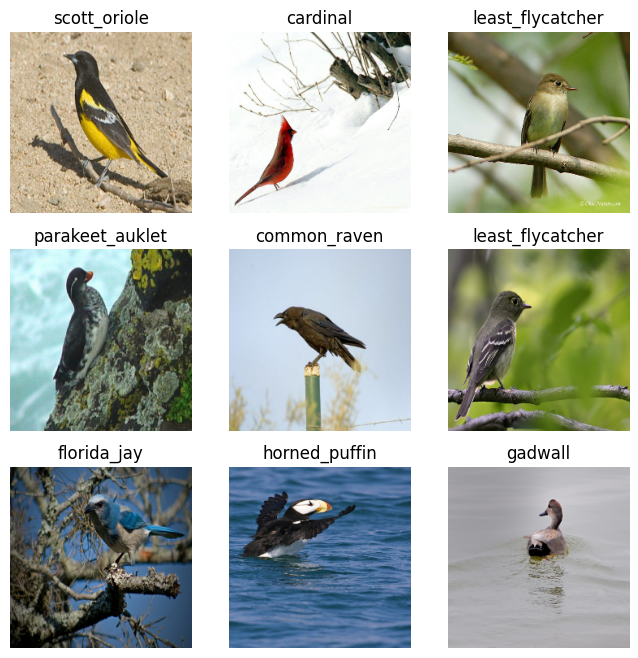

In [ ]:
#visual check
import matplotlib.pyplot as plt

images, labels = next(iter(train_ds))
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i].numpy()])
    plt.axis("off")
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# Method 1: Baseline CNN

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# build the CNN (what learns to recognize patterns)
def tiny_cnn(num_classes):
    inputs = keras.Input(shape=IMG_SIZE + (3,))     # 224x224 RGB
    x = layers.Rescaling(1./255)(inputs)            # scale pixels to [0,1]
    x = layers.Conv2D(32, 3, activation="relu")(x)  # edges/colors
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)  # bigger shapes
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x) # detailed features
    x = layers.GlobalAveragePooling2D()(x)          # compress features
    x = layers.Dropout(0.3)(x)                      # reduce overfitting
    outputs = layers.Dense(num_classes, activation="softmax")(x)  # class probs
    return keras.Model(inputs, outputs)

# build the model and prepare it for training
model = tiny_cnn(num_classes)


model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

# train the model (learn from train_ds; validate on unseen val_ds each epoch)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=4,
            restore_best_weights=True
        )
    ]
)

## Baseline CNN Results
and saved to result folder

In [ ]:
# Save model, plots, and evaluation results
import os, json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

SAVE_DIR = "/content/drive/MyDrive/Bird Project/results/baseline_cnn_new"
os.makedirs(SAVE_DIR, exist_ok=True)

# Save model + training info
model.save(f"{SAVE_DIR}/baseline_cnn.keras")
with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f)
with open(f"{SAVE_DIR}/history.json", "w") as f:
    json.dump(history.history, f)

# Plot accuracy and loss
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Baseline CNN — Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.savefig(f"{SAVE_DIR}/baseline_accuracy.png", dpi=160)
plt.close()

plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Baseline CNN — Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.savefig(f"{SAVE_DIR}/baseline_loss.png", dpi=160)
plt.close()

# Evaluate and report
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.concatenate([np.argmax(model.predict(x, verbose=0), axis=1) for x, _ in test_ds])

report = classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro")

with open(f"{SAVE_DIR}/baseline_report.txt", "w") as f:
    f.write(report + f"\nMacro-F1: {macro_f1:.3f}\n")

print(report)
print("Macro-F1:", macro_f1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title('Baseline CNN — Confusion Matrix')
plt.colorbar()
plt.xticks([]); plt.yticks([])  # too many classes
plt.tight_layout()
plt.xlabel('Predicted'); plt.ylabel('True')
plt.savefig(f"{SAVE_DIR}/baseline_confusion_matrix.png", dpi=180, bbox_inches='tight')
plt.close()

# Method 2: Transfer Learning with ResNet50

Using a pretrained ResNet50 model from ImageNet instead of training from scratch.  
We freeze most of the base layers and only train the new classification head.  
Goal: improve accuracy and reduce training time compared to the baseline CNN.

#Training the model (resnet50):

In [ ]:
# --- Method 2: Transfer Learning with ResNet50 (compact) ---
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
import os, json, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score

RES_DIR = "/content/drive/MyDrive/Bird Project/results/resnet50"
os.makedirs(RES_DIR, exist_ok=True)

# Build model (head-only)
base = ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE+(3,), name="resnet50_base")
base.trainable = False
inp = keras.Input(shape=IMG_SIZE+(3,))
x = preprocess_input(inp)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inp, out, name="resnet50_head")

# Train head
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
hist_head = model.fit(train_ds, validation_data=val_ds, epochs=8,
                      callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)])

# light fine-tune last ~50 layers
base.trainable = True
for l in base.layers[:-50]:
    l.trainable = False
model.compile(optimizer=keras.optimizers.Adam(1e-4),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
hist_ft = model.fit(train_ds, validation_data=val_ds, epochs=6,
                    callbacks=[keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=2, restore_best_weights=True)])

# Save curves (1 image for acc, 1 for loss)
def _save_curves(hist, title_prefix, path_prefix):
    acc = hist.history.get("accuracy", []); val_acc = hist.history.get("val_accuracy", [])
    loss = hist.history.get("loss", []);    val_loss = hist.history.get("val_loss", [])
    plt.figure(); plt.plot(acc,label="train"); plt.plot(val_acc,label="val"); plt.title(f"{title_prefix} — Accuracy"); plt.legend()
    plt.savefig(f"{RES_DIR}/{path_prefix}_accuracy.png", dpi=160); plt.close()
    plt.figure(); plt.plot(loss,label="train"); plt.plot(val_loss,label="val"); plt.title(f"{title_prefix} — Loss"); plt.legend()
    plt.savefig(f"{RES_DIR}/{path_prefix}_loss.png", dpi=160); plt.close()

_save_curves(hist_head, "ResNet50 (head-only)", "resnet50_head")
_save_curves(hist_ft,   "ResNet50 (fine-tuned)", "resnet50_ft")

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.concatenate([np.argmax(model.predict(x, verbose=0), axis=1) for x, _ in test_ds])
report = classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro")

# Save model + report
model.save(f"{RES_DIR}/resnet50_finetuned.keras")
with open(f"{RES_DIR}/resnet50_report.txt","w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\nTest loss: {test_loss:.4f}\nMacro-F1: {macro_f1:.3f}\n\n{report}")

print(f"ResNet50 — Test acc: {test_acc:.4f} | Macro-F1: {macro_f1:.3f}")

Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1609s 6s/step - accuracy: 0.1438 - loss: 4.5439 - val_accuracy: 0.4771 - val_loss: 2.0100
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1587s 6s/step - accuracy: 0.6311 - loss: 1.4457 - val_accuracy: 0.5518 - val_loss: 1.6511
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1590s 6s/step - accuracy: 0.7748 - loss: 0.8954 - val_accuracy: 0.5900 - val_loss: 1.5192
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1637s 6s/step - accuracy: 0.8527 - loss: 0.6001 - val_accuracy: 0.5953 - val_loss: 1.5050
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1649s 6s/step - accuracy: 0.9053 - loss: 0.4355 - val_accuracy: 0.6126 - val_loss: 1.4468
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1642s 6s/step - accuracy: 0.9220 - loss: 0.3473 - val_accuracy: 0.6091 - val_loss: 1.4139
Epoch 7/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1592s 6s/step - accuracy: 0.9457 - loss: 0.2628 - val_accuracy: 0.6103 - val_loss: 1.4382
Epoch 8/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 1637s 6s/step - accuracy: 0.9527 - loss: 0.2219 - val_accu

#Testing the model with unseen data from training then saving it with confusion matrix image

In [ ]:
import numpy as np, matplotlib.pyplot as plt, os, json
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd  # for saving cm as CSV

# pick model to evaluate
MODEL_PATH = f"{RES_DIR}/resnet50_finetuned.keras"  # or f"{RES_DIR}/resnet50_head_only.keras"
model_eval = keras.models.load_model(MODEL_PATH)

# test metrics (accuracy/loss)
test_loss, test_acc = model_eval.evaluate(test_ds, verbose=0)

# predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.concatenate([np.argmax(model_eval.predict(x, verbose=0), axis=1) for x, _ in test_ds])

# report + macro F1
report = classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro")

# save report
with open(f"{RES_DIR}/resnet50_test_report.txt", "w") as f:
    f.write(f"Model: {os.path.basename(MODEL_PATH)}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\nTest loss: {test_loss:.4f}\nMacro-F1: {macro_f1:.3f}\n\n")
    f.write(report)

print(f"Model: {os.path.basename(MODEL_PATH)} | Test acc: {test_acc:.4f} | Macro-F1: {macro_f1:.3f}")
print(report)

# confusion matrix: save CSV + minimal preview PNG
cm = confusion_matrix(y_true, y_pred)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(f"{RES_DIR}/resnet50_confusion_matrix.csv")

plt.figure(figsize=(6.5,6.5))
plt.imshow(cm, interpolation="nearest")
plt.title("ResNet50 — Confusion Matrix (see CSV for labels)")
plt.colorbar()
plt.xticks([]); plt.yticks([])  # hide crowded labels
plt.tight_layout()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.savefig(f"{RES_DIR}/resnet50_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

Model: resnet50_finetuned.keras | Test acc: 0.7009 | Macro-F1: 0.701
                                precision    recall  f1-score   support

            acadian_flycatcher      0.538     0.700     0.609        10
                 american_crow      0.167     0.222     0.190         9
            american_goldfinch      0.875     0.778     0.824         9
                american_pipit      0.545     0.667     0.600         9
             american_redstart      0.750     1.000     0.857         9
american_three_toed_woodpecker      0.875     0.875     0.875         8
              anna_hummingbird      0.857     0.667     0.750         9
                    artic_tern      0.625     1.000     0.769        10
                 baird_sparrow      0.600     0.750     0.667         8
              baltimore_oriole      0.875     0.778     0.824         9
                  bank_swallow      0.600     0.600     0.600        10
                  barn_swallow      0.583     0.778     0.667     

Method 3
: Transfer Learning with EfficientNet
Using a pretrained EfficientNet model from ImageNet to train in addition of ResNet50 model

Goal: improve accuracy and testing quality compared to the other 2 previous model.

In [ ]:
# --- Method 3: Transfer Learning with EfficientNet (compact) ---
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
import os, json, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import classification_report, f1_score

RES_DIR = "/content/drive/MyDrive/Bird Project/results/efficientnet"
os.makedirs(RES_DIR, exist_ok=True)

# Build EfficientNet model (head-only)
base = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False  # freeze backbone initially

inp = keras.Input(shape=IMG_SIZE + (3,))
x = preprocess_input(inp)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inp, out, name="efficientnet_head")

# --- Stage 1: Train classifier head ---
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
hist_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=3,
            restore_best_weights=True
        )
    ]
)

# --- Stage 2: Fine-tune top EfficientNet layers ---
base.trainable = True
for l in base.layers[:-50]:  # unfreeze last ~50 layers
    l.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
hist_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=2,
            restore_best_weights=True
        )
    ]
)

# --- Save accuracy/loss curves ---
def _save_curves(hist, title_prefix, path_prefix):
    acc = hist.history.get("accuracy", []); val_acc = hist.history.get("val_accuracy", [])
    loss = hist.history.get("loss", []);    val_loss = hist.history.get("val_loss", [])
    plt.figure(); plt.plot(acc,label="train"); plt.plot(val_acc,label="val")
    plt.title(f"{title_prefix} — Accuracy"); plt.legend()
    plt.savefig(f"{RES_DIR}/{path_prefix}_accuracy.png", dpi=160); plt.close()
    plt.figure(); plt.plot(loss,label="train"); plt.plot(val_loss,label="val")
    plt.title(f"{title_prefix} — Loss"); plt.legend()
    plt.savefig(f"{RES_DIR}/{path_prefix}_loss.png", dpi=160); plt.close()

_save_curves(hist_head, "EfficientNet (head-only)", "efficientnet_head")
_save_curves(hist_ft,   "EfficientNet (fine-tuned)", "efficientnet_ft")

# --- Evaluate on test set ---
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.concatenate([np.argmax(model.predict(x, verbose=0), axis=1) for x, _ in test_ds])
report = classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro")

# --- Save model + report ---
model.save(f"{RES_DIR}/efficientnet_finetuned.keras")
with open(f"{RES_DIR}/efficientnet_report.txt", "w") as f:
    f.write(f"Test accuracy: {test_acc:.4f}\nTest loss: {test_loss:.4f}\nMacro-F1: {macro_f1:.3f}\n\n{report}")

print(f"EfficientNet — Test acc: {test_acc:.4f} | Macro-F1: {macro_f1:.3f}")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.1658 - loss: 4.2924 - val_accuracy: 0.5594 - val_loss: 2.1597
Epoch 2/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.6076 - loss: 1.9085 - val_accuracy: 0.6508 - val_loss: 1.5801
Epoch 3/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 497s 2s/step - accuracy: 0.7211 - loss: 1.3158 - val_accuracy: 0.6757 - val_loss: 1.3518
Epoch 4/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.7740 - loss: 1.0691 - val_accuracy: 0.6943 - val_loss: 1.2405
Epoch 5/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 613s 2s/step - accuracy: 0.8057 - loss: 0.9016 - val_accuracy: 0.6948 - val_loss: 1.1653
Epoch 6/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 493s 2s/step - accuracy: 0.8262 - loss: 0.7935 - val_accuracy: 0.7099 - val_loss: 1.1099
Epoch 7/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.8535 - loss: 0.7049 - val_accuracy: 0.7151 - val_loss: 1.0699
Epoch 8/8
258/258 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step -

#Testing the model with unseen data from training then saving it with confusion matrix image

In [ ]:
import numpy as np, matplotlib.pyplot as plt, os, json
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd  # for saving cm as CSV

# pick model to evaluate
MODEL_PATH = f"{RES_DIR}/efficientnet_finetuned.keras"  # or f"{RES_DIR}/resnet50_head_only.keras"
model_eval = keras.models.load_model(MODEL_PATH)

# test metrics (accuracy/loss)
test_loss, test_acc = model_eval.evaluate(test_ds, verbose=0)

# predictions
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = np.concatenate([np.argmax(model_eval.predict(x, verbose=0), axis=1) for x, _ in test_ds])

# report + macro F1
report = classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro")

# save report
with open(f"{RES_DIR}/efficientnet_test_report.txt", "w") as f:
    f.write(f"Model: {os.path.basename(MODEL_PATH)}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\nTest loss: {test_loss:.4f}\nMacro-F1: {macro_f1:.3f}\n\n")
    f.write(report)

print(f"Model: {os.path.basename(MODEL_PATH)} | Test acc: {test_acc:.4f} | Macro-F1: {macro_f1:.3f}")
print(report)

# confusion matrix: save CSV + minimal preview PNG
cm = confusion_matrix(y_true, y_pred)
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(f"{RES_DIR}/efficientnet_confusion_matrix.csv")

plt.figure(figsize=(6.5,6.5))
plt.imshow(cm, interpolation="nearest")
plt.title("efficientnet — Confusion Matrix (see CSV for labels)")
plt.colorbar()
plt.xticks([]); plt.yticks([])  # hide crowded labels
plt.tight_layout()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.savefig(f"{RES_DIR}/efficientnet_confusion_matrix.png", dpi=180, bbox_inches="tight")
plt.close()

Model: efficientnet_finetuned.keras | Test acc: 0.7753 | Macro-F1: 0.773
                                precision    recall  f1-score   support

            acadian_flycatcher      0.636     0.700     0.667        10
                 american_crow      0.571     0.444     0.500         9
            american_goldfinch      0.875     0.778     0.824         9
                american_pipit      1.000     0.667     0.800         9
             american_redstart      0.900     1.000     0.947         9
american_three_toed_woodpecker      0.800     1.000     0.889         8
              anna_hummingbird      0.625     0.556     0.588         9
                    artic_tern      0.692     0.900     0.783        10
                 baird_sparrow      0.700     0.875     0.778         8
              baltimore_oriole      0.750     0.667     0.706         9
                  bank_swallow      0.538     0.700     0.609        10
                  barn_swallow      0.818     1.000     0.900 

# TL;DR – What We Did

**Dataset:**  
Loaded the bird species dataset from Kaggle, split into training, validation, and test sets.

**Method 1 – Baseline CNN:**  
- Built and trained a simple convolutional neural network from scratch.  
- Performance was low, indicating the challenge of training a CNN from scratch on this dataset without transfer learning.  
- Saved model, accuracy/loss plots, and confusion matrix to Drive.

**Method 2 – Transfer Learning (ResNet50):**  
- Used a pretrained ResNet50 model (trained on ImageNet).  
- Froze base layers and trained a new classification head.  
- Fine-tuned top layers for better accuracy.  
- Achieved a test accuracy of approximately **70.1%** and a Macro-F1 score of **0.701**.  
- Saved model, training plots, and evaluation report to Drive.

**Method 3 – Transfer Learning (EfficientNet):**  
- Used a pretrained EfficientNetV2B0 model (trained on ImageNet).  
- Froze base layers and trained a new classification head.  
- Fine-tuned top layers for further improvements.  
- Achieved a test accuracy of approximately **77.5%** and a Macro-F1 score of **0.773**, outperforming the ResNet50 model.  

**Key Takeaway:**  
Transfer learning significantly improved model performance and generalization compared to a CNN trained from scratch, with EfficientNet showing the best results.
All trained models and results can be found in our shared Drive folder under `/Bird Project/results/`.